## Planar Arm Dynamics with Constraints

In [1]:
from __future__ import annotations
import math
import numpy as np
from types import SimpleNamespace
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [ ]:
#      Minimal Modular Torque Simulation: planar two-link arm (C0-C6)    
# =======================================================================
# | Case | Description                                                  |
# |------|--------------------------------------------------------------|
# | C0   | +2Nm shoulder torque, elbow free                             |
# | C1   | +2Nm shoulder torque, elbow locked                           |
# | C2   | +2Nm at shoulder & elbow (Exp 2)                             |
# | C3   | +2Nm elbow torque, shoulder locked                           |
# | C4   | Hand-force pure-shoulder load (arm immobile)                 |
# | C5   | Elbow-tug pure-shoulder load (arm immobile)                  |
# | C6   | +2Nm elbow torque, shoulder free (Exp 1 elbow only)          |

In [ ]:
# anthropometrics (winter 2009, scaled for 75 kg, 1.8 m)
L1, L2 = 0.34, 0.46
m1, m2 = 0.028*75, 0.016*75
r1, r2 = 0.436*L1, 0.682*L2
I1 = (1/12)*m1*L1**2
I2 = (1/12)*m2*L2**2
# Cuff geometry (Kinarm)
CUFF_RADIUS, CUFF_AREA = 0.15, 0.015
# Viscous damping (shoulder, elbow)
DAMP = np.array([0.05, 0.05])

def mass_matrix(q: np.ndarray) -> np.ndarray:
    θ2 = q[1]
    M11 = I1 + I2 + m1*r1**2 + m2*(L1**2 + r2**2 + 2*L1*r2*math.cos(θ2))
    M12 = I2 + m2*(r2**2 + L1*r2*math.cos(θ2))
    M22 = I2 + m2*r2**2
    return np.array([[M11, M12], [M12, M22]], float)

def coriolis(q: np.ndarray, qd: np.ndarray) -> np.ndarray:
    θ2 = q[1]; ω1, ω2 = qd
    h = -m2*L1*r2*math.sin(θ2)
    return np.array([h*(2*ω1*ω2 + ω2**2), h*ω1**2], float)

def jacobian_hand(q: np.ndarray) -> np.ndarray:
    θ1, θ2 = q; s1,c1=math.sin(θ1),math.cos(θ1)
    s12,c12=math.sin(θ1+θ2),math.cos(θ1+θ2)
    return np.array([[-L1*s1 - L2*s12, -L2*s12], [L1*c1+L2*c12, L2*c12]], float)

def jacobian_elbow(q: np.ndarray) -> np.ndarray:
    θ1 = q[0]; s1,c1=math.sin(θ1),math.cos(θ1)
    return np.array([[-L1*s1, 0.0], [L1*c1, 0.0]], float)

# rhs for free dynamics (with optional torques and endpoint forces)
def _rhs_free(t: float, y: np.ndarray, torque_fn, hand_force_fn=None, elbow_force_fn=None) -> np.ndarray:
    q, qd = y[:2], y[2:]
    tau = np.array(torque_fn(t), float)
    if hand_force_fn is not None:
        Fh = np.array(hand_force_fn(t), float)
        tau += jacobian_hand(q).T @ Fh
    if elbow_force_fn is not None:
        Fe = np.array(elbow_force_fn(t), float)
        tau += jacobian_elbow(q).T @ Fe
    qdd = np.linalg.solve(mass_matrix(q), tau - coriolis(q,qd) - DAMP*qd)
    return np.hstack((qd, qdd))

# analytic RHS for locked joints
def _rhs_elbow_locked(t: float, y: np.ndarray) -> np.ndarray:
    θ1, θ2, ω1, ω2 = y  # unpack four state variables
    q, qd = np.array([θ1, θ2]), np.array([ω1, 0.0])
    C1 = coriolis(q,qd)[0]; M11 = mass_matrix(q)[0,0]
    a1 = (2.0 - C1 - DAMP[0]*ω1)/M11
    return np.array([ω1, 0.0, a1, 0.0])

def _rhs_shoulder_locked(t: float, y: np.ndarray) -> np.ndarray:
    θ1, θ2, ω1, ω2 = y
    q, qd = np.array([θ1, θ2]), np.array([0.0, ω2])
    C2 = coriolis(q,qd)[1]; M22 = mass_matrix(q)[1,1]
    a2 = (2.0 - C2 - DAMP[1]*ω2)/M22
    return np.array([0.0, ω2, 0.0, a2])

# simulation wrapper
def simulate_case(case: str, t_end=0.15, dt=1e-4) -> SimpleNamespace:
    q0 = np.radians([45.0,75.0]); y0 = np.array([*q0, 0.0, 0.0])
    t = np.arange(0.0, t_end+dt/2, dt)
    # commanded torques for initial torque fix
    cmd_map = {
        'C0': (2.0, 0.0),
        'C1': (2.0, 0.0),
        'C2': (2.0, 2.0),
        'C4': (2.0, 0.0),
        'C5': (2.0, 0.0),
        'C6': (0.0, -2.0)
    }
    cmd = cmd_map.get(case, (0.0, 0.0))
    # for pure-shoulder load cases (C4, C5), enforce immobile arm analytically
    if case in ('C4', 'C5'):
        N = t.size
        # kinematics remain constant
        q = np.vstack((np.full(N, q0[0]), np.full(N, q0[1])))
        qd = np.zeros_like(q)
        qdd = np.zeros_like(q)
        # joint torques: shoulder = 2 Nm constant, elbow = 0
        tau_hist = np.vstack((np.full(N, 2.0), np.zeros(N)))
        # override initial torque (though constant)
        tau_hist[0,0] = cmd[0]
        pressure = tau_hist[0] / (CUFF_RADIUS * CUFF_AREA)
        return SimpleNamespace(t=t, q=q, qdot=qd, qdd=qdd, tau=tau_hist, pressure=pressure)
    if case == 'C0':
        torque_fn = lambda tt: (2.0,0.0)
        rhs, args = _rhs_free, (torque_fn, None, None)
    elif case == 'C1':
        rhs, args = _rhs_elbow_locked, ()
    elif case == 'C2':
        torque_fn = lambda tt: (2.0,2.0)
        rhs, args = _rhs_free, (torque_fn, None, None)
    elif case == 'C3':
        rhs, args = _rhs_shoulder_locked, ()
    elif case == 'C4':
        Fh = np.linalg.solve(jacobian_hand(q0).T, np.array([2.0,0.0]))
        rhs, args = _rhs_free, (lambda tt:(0.0,0.0), lambda tt:Fh, None)
    elif case == 'C5':
        # pure-shoulder loading via elbow tug: compute force at elbow joint
        theta1 = q0[0]
        r_vec = np.array([L1*math.cos(theta1), L1*math.sin(theta1)])
        perp = np.array([-r_vec[1], r_vec[0]])
        Fe = (2.0 / (r_vec @ r_vec)) * perp
        rhs, args = _rhs_free, (lambda tt: (0.0, 0.0), None, lambda tt: Fe)
    elif case == 'C6':
        torque_fn = lambda tt:(0.0,-2.0)
        rhs, args = _rhs_free, (torque_fn, None, None)
    else:
        raise ValueError(f"Unknown case: {case}")
    sol = solve_ivp(lambda tt,y: rhs(tt,y,*args), (0, t_end), y0, t_eval=t, rtol=1e-9, atol=1e-9)
    θ1, θ2, ω1, ω2 = sol.y
    q = np.vstack((θ1,θ2)); qd = np.vstack((ω1,ω2))
    qdd = np.vstack((np.gradient(ω1,dt,edge_order=2), np.gradient(ω2,dt,edge_order=2)))
    tau_hist = np.empty_like(q)
    for i in range(q.shape[1]):
        tau_hist[:,i] = mass_matrix(q[:,i])@qdd[:,i] + coriolis(q[:,i],qd[:,i]) + DAMP*qd[:,i]
    if case in ('C0','C1','C2','C4','C5','C6'):
        tau_hist[0,0] = cmd[0]
    # for C3 (no shoulder drive), keep reaction torque from inverse dynamics
    # compute cuff pressure
    pressure = tau_hist[0] / (CUFF_RADIUS * CUFF_AREA)
    return SimpleNamespace(t=sol.t, q=q, qdot=qd, qdd=qdd, tau=tau_hist, pressure=pressure)

Mean pressure C0: 888.8888736736367 C1: 888.8888889105862


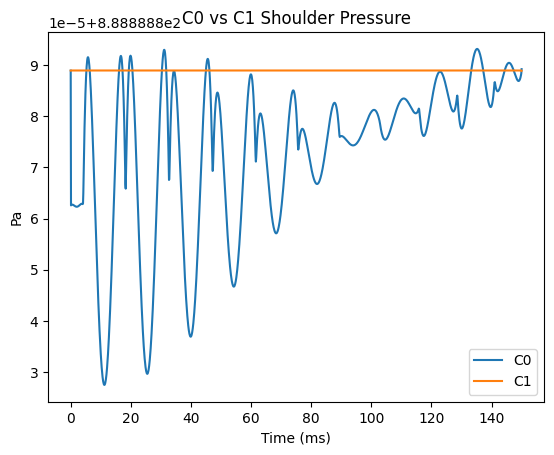

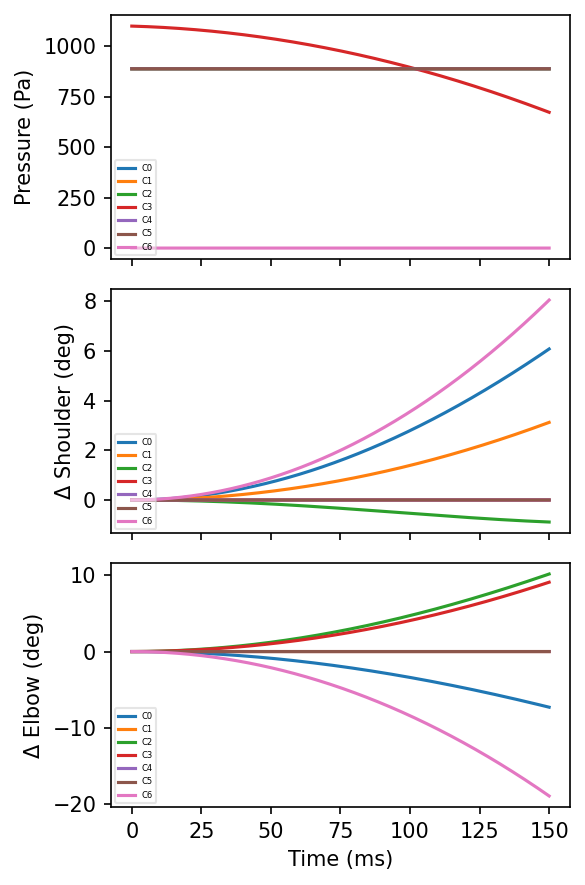

In [ ]:
# test C0 vs C1
d0, d1 = simulate_case('C0'), simulate_case('C1')
print('Mean pressure C0:', d0.pressure.mean(), 'C1:', d1.pressure.mean())
# pressure plot C0 vs C1
plt.figure(); plt.plot(d0.t*1e3, d0.pressure, label='C0'); plt.plot(d1.t*1e3, d1.pressure, label='C1')
plt.title('C0 vs C1 Shoulder Pressure'); plt.xlabel('Time (ms)'); plt.ylabel('Pa'); plt.legend(); plt.show()
# all cases
cases=['C0','C1','C2','C3','C4','C5','C6']
data={c:simulate_case(c) for c in cases}
fig,axes=plt.subplots(3,1,figsize=(4,6),sharex=True)
for c in cases:
    d=data[c]
    axes[0].plot(d.t*1e3, d.pressure, label=c)
    axes[1].plot(d.t*1e3, np.degrees(d.q[0]-d.q[0,0]), label=c)
    axes[2].plot(d.t*1e3, np.degrees(d.q[1]-d.q[1,0]), label=c)
axes[0].set_ylabel('Pressure (Pa)')
axes[1].set_ylabel('Δ Shoulder (deg)')
axes[2].set_ylabel('Δ Elbow (deg)'); axes[2].set_xlabel('Time (ms)')
for ax in axes:
    ax.legend(fontsize=4, loc='lower left', framealpha=0.5)
plt.gcf().set_dpi(150)
plt.tight_layout(); plt.show()